# Метод опорных векторов

**Метод опорных векторов (Support Vector Machine — SVM)** — это универсальная модель машинного обучения, способная выполнять линейную или нелинейную классификацию, регрессию и даже выявление выбросов. Она является одной из самых популярных моделей в МО.

Методы SVM особенно хорошо подходят для классификации сложных, но
небольших или средних наборов данных.

Основной принцип работы SVM чем-то похож на алгоритмы линейной и логистической регрессий. SVM ищет оптимальную гиперплоскость, которая максимально разделяет классы (в случае классификации) или проходит как можно ближе к точкам (в случае регрессии). Только для работы он использует не одну гиперплоскость (как в случае с линейной и логистической регрессией), а несколько. Конечно, математические основы тоже отличаются, но если сделать грубое округление, то можно провести некоторую аналогию между этими алгоритмами.

Давайте для начала разберемся с общим определением алгоритма и основными понятиями, которые использует SVM.

**Метод опорных векторов (Support Vector Machine, SVM)** — это алгоритм машинного обучения с учителем, который решает задачи классификации и регрессии, находя оптимальную гиперплоскость, которая максимально разделяет данные разных классов в пространстве признаков.

Его ключевая идея — найти такую гиперплоскость, чтобы зазор (margin) между ближайшими точками классов был максимальным.

______________

**Гиперплоскость (Hyperplane)** — это обобщение прямой на многомерное пространство. В 2D — это прямая, в 3D — плоскость, в $n$-мерном пространстве — гиперплоскость размерности $n-1$.

Пусть задана обучающая выборка пар «объект-ответ»: $(X_i, y_i)_{i=1}^n$

где:
- $X_i (x_i^1, x_i^2, ..., x_i^d)$ вектор признаков для $i$-го объекта (верхний индекс — это индекс определенного признака (это не степень!), нижний индекс — это индекс объекта),
- $d$ количество признаков,
- $n$ количество объектов в выборке,
- $y_i$ правильный ответ для $i$-го объекта.

Вспомним общее уравнение гиперплоскости:

$$f_{w,b}(x) = w_1*x_1 + w_2*x_2 + \dots + w_n*x_n + b = \left \langle w,x \right \rangle + b = \sum^{n}_{i=1}w_{i}x_{i} + b$$
,

где:

 — $X_i$ - вектор $i$-го признака для объектов,
 — $w$ - вектор коэффициентов, перпендикулярный гиперплоскости

В методе опорных векторов вектор $w$ — это нормаль к гиперплоскости. То есть он задает направление этой плоскости в пространстве признаков, определяет геометрию границы разделения классов.

_______

**Опорные векторы (Support Vectors)** — это точки, которые лежат на границе зазора или внутри него. Они определяют положение гиперплоскости.

Только эти точки важны для построения разделяющей границы, остальные — нет.

_______

**Зазор (margin)** — это расстояние от гиперплоскости до ближайших точек каждого класса. Это ширина зазора между двумя параллельными гиперплоскостями, которые максимально удалены друг от друга, но при этом касаются ближайших точек каждого из классов (опорных векторов).
$end

Зазоры бывают двух видов.

- Жесткий зазор (hard margin) — это строгое разделение без ошибок, когда все обучающие образцы должны быть правильно классифицированы и находиться за пределами полосы разделения. Такой подход работает только в случае хорошей линейной разделимости данных и является довольно чувствительным к выбросам.
- Мягкий зазор (soft margin) — зазор, когда допускается небольшое количество ошибок (если данные не линейно-разделимы). То есть когда вводится допущение, что некоторые обучающие образцы могут нарушать условие правильной классификации или попадать в полосу разделения, но при этом вводится штраф за такие нарушения, пропорциональный параметру  (чем ниже данное значение, тем шире полоса и больше нарушений попадает в зазор). При таком подходе увеличивается обобщающая способность модели, что позволяет снизить риск переобучения.

**Формула зазора (margin):**

$$
M = \frac{2}{||w||}
$$

где:
 — $w$ - вектор весов (нормаль к разделяющей гиперплоскости).
 — $||w||$ - норма (длина) вектора весов: $||w|| = \sqrt{w_1^2 + w_2^2 + ... + w_d^2}$.


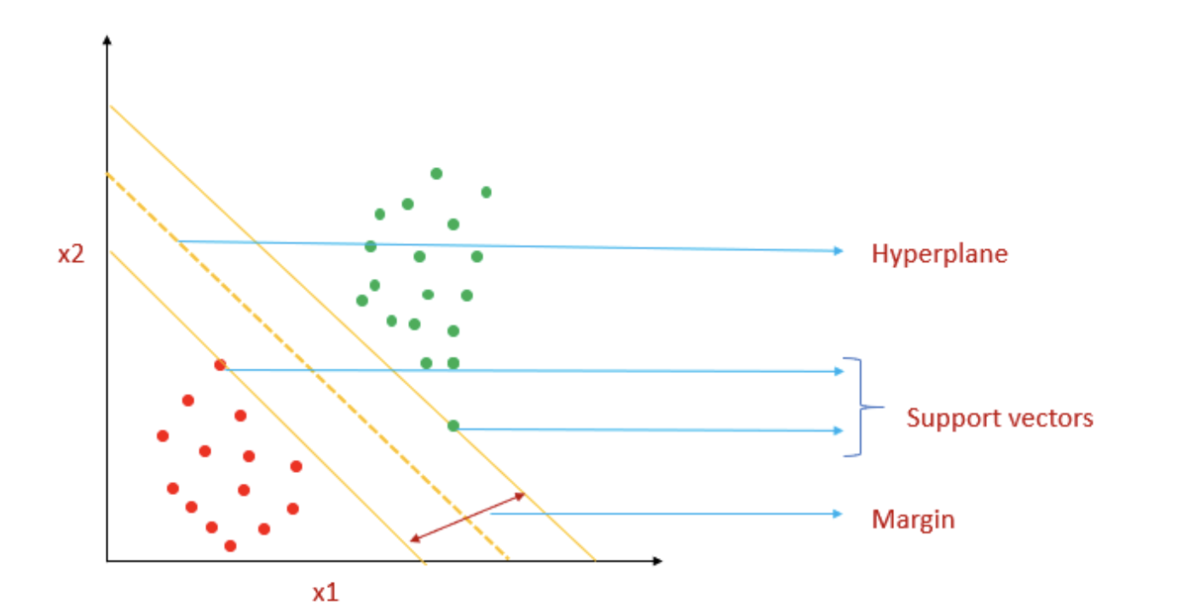

Рассмотрим разные случаи, чтобы до конца понять принцип работы алгоритма:
1. Линейная классификация на два класса.
2. Линейная классификация на более, чем 2 класса.
3. Нелинейная классификация.
4. Регрессия.

Но для начала введем еще одно определение.

**Ядро SVM** — это математическая функция, которая используется в SVM для отображения исходных точек входных данных в более высокоразмерное пространство признаков, где гиперплоскость можно легко найти, даже если точки данных не являются линейно разделимыми в исходном пространстве. Ядро помогает строить сложные разделяющие границы (особенно в нелинейном случае) без явного преобразования признаков.

С математической точки зрения:
$$
K(X_i, X_j) = \phi(X_i) * \phi(X_j)
$$

где:

- $X_i, X_j$ - векторы признаков для двух объектов,
- $\phi(X)$ - функция отображения в новое (возможно, бесконечномерное) пространство.

Вместо явного перехода к новому пространству просто считаем скалярное произведение в этом пространстве с помощью ядра! Это называется **ядровым трюком (Kernel trick)**.

Но про ядро и его использование поговорим чуть позже.


## Линейная классификация на 2 класса

Здесь все просто: если данные линейно разделимы, SVM ищет одну гиперплоскость, которая максимально разделяет два класса.
На графике слева показаны границы решений для трех различных линейных классификаторов.

Одна модель (розовая линия) работает плохо — она даже не разделяет классы правильно.

Две другие модели (с красной и оранжевой границами) отлично справляются с разметкой обучающей выборки. Но их границы решений проходят слишком близко к точкам, что может привести к переобучению. Из-за этого модели могут плохо обобщаться на новые данные, которые она не видела ранее.


**Классификатор SVM** (метод опорных векторов) пытается не просто провести линию, которая разделяет классы, а найти такую границу, чтобы она находилась как можно дальше от самых близких точек каждого класса. Эта разделяющая линия называется гиперплоскостью.

А параллельные пунктирные линии показывают границы полосы максимального зазора — области, где нет точек. На рисунке справа показана визуализация алгоритма SVM.

Почему это важно?
- Чем шире полоса, тем надежнее классификация: модель становится более устойчивой к шуму и новым данным.
- Опорные векторы — это точки, которые лежат на границе зазора или внутри него. Именно они определяют положение разделяющей линии.
- В итоге SVM выбирает самую «осторожную» границу, которая максимально отдалена от самых близких точек обоих классов — это называется классификацией с широким зазором (Large Margin Classification).

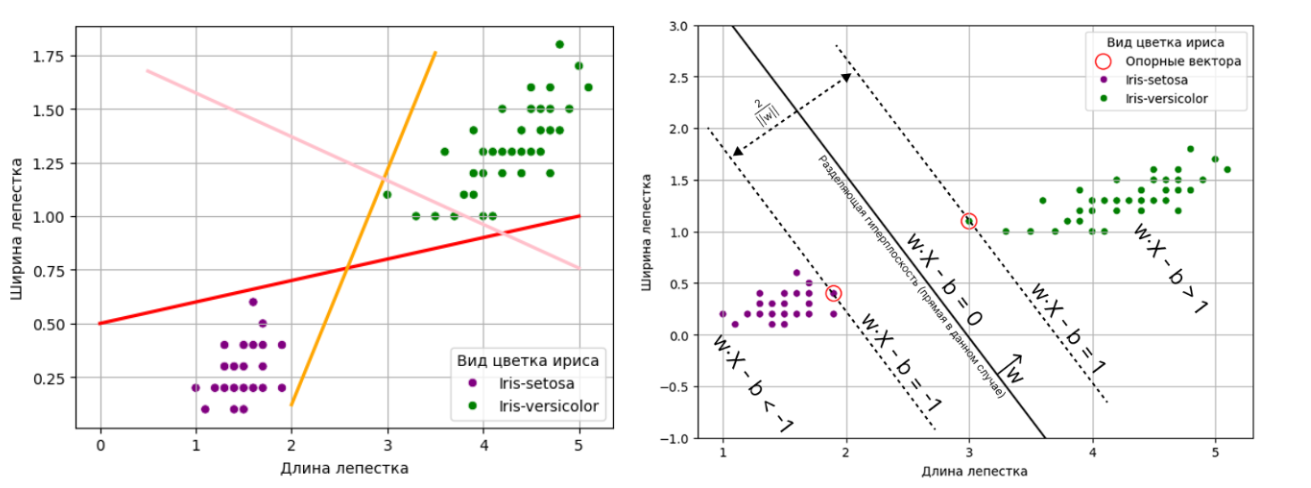

## Линейная классификация на более, чем 2 класса

SVM — изначально бинарный классификатор. Чтобы обрабатывать много классов, используют стратегии многоклассовой классификации, которые мы обсуждали в предыдущих лекциях.

1. One-vs-One (OvO)

Строится отдельный SVM для каждой пары классов.
Для  классов строится  моделей. Итоговая классификация — по голосованию: какой класс победил в большинстве парных классификаций, тот и присваивается объекту.

Такая стратегия хорошо работает на небольших данных. Но большое количество моделей слишком ресурсоемко для большого числа классов.

2. One-vs-Rest (OvR)

Строится K SVM-классификаторов. Каждый SVM учится отличать один класс от всех остальных. Итоговый класс — тот, у которого предсказанная оценка (отступ) самая большая.


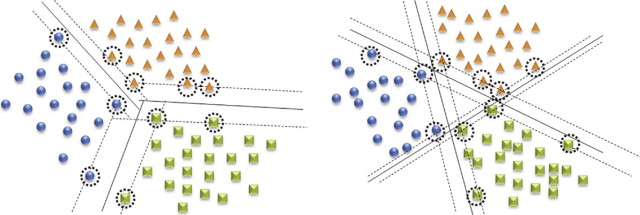

## Нелинейная классификация

Рассмотрим простую ситуацию: есть два класса, но они распределены по кругу. Прямая линия никак не сможет их разделить. В таких случаях нам нужна модель, которая может строить более сложные границы решений.

Чтобы сделать SVM нелинейным, используется метод ядра (kernel trick). Идея в том, чтобы преобразовать исходное пространство признаков в пространство большей размерности, где классы становятся линейно разделимыми.

Формально вместо того, чтобы явно вычислять преобразование, мы используем **ядровую функцию**:

$$
K(X_i, X_j) = \phi(X_i) * \phi(X_j)
$$

где:

- $X_i, X_j$ - векторы признаков для двух объектов,
- $\phi(X)$ - функция отображения в новое (возможно, бесконечномерное) пространство.

SVM работает напрямую с этим скалярным произведением, что позволяет эффективно находить оптимальные разделяющие гиперплоскости.

Теперь давайте подробнее рассмотрим пример с двумя окружностями:
Допустим, есть данные в 2D, которые не линейно разделимы, две окружности. Линейная граница не справится. Но можно применить преобразование:

$(x, y) = (x,y, x^2+y^2)$. Теперь точки из плоскости переносятся на параболоид в 3D, и там уже можно провести плоскость, которая разделяет классы.

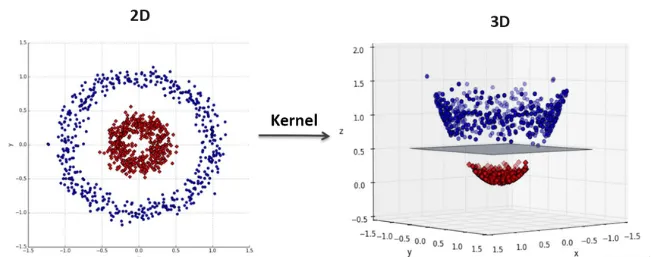

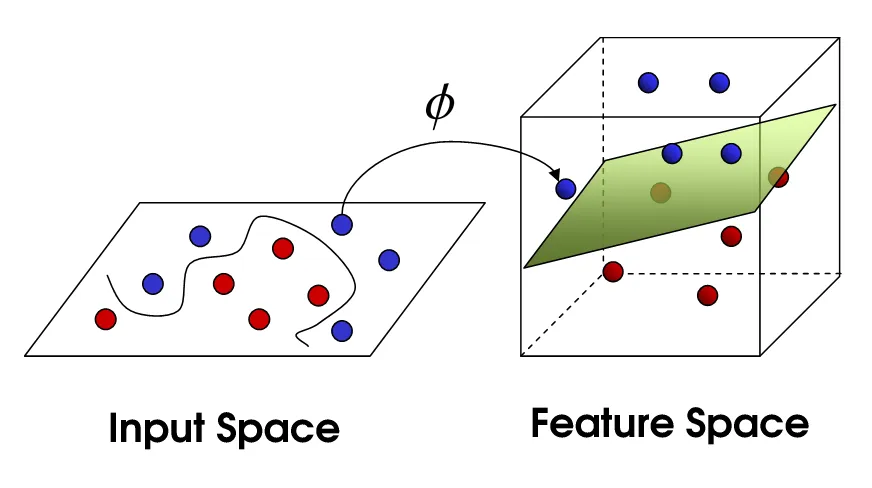

**Популярные ядра в SVM**

1. Линейное ядро, с которым мы уже познакомились в предыдущем уроке: $K(x_i, x_j) = x_i \cdot x_j$.
2. Полиномиальное ядро, которое позволяет находить многочленные зависимости: $K(x_i, x_j) = (x_i \cdot x_j + C)^d$, где $C$ — константа, а  $d$— степень полинома.
3. RBF (гауссово) ядро — часто самое мощное, позволяет строить сложные искривленные границы: $K(x_i, x_j) =exp(-\gamma \cdot ||x_i - x_j||^2)$.

Вот простая и интересная статья о математических основах RBF-ядра: https://blog.dailydoseofds.com/p/the-mathematics-behind-rbf-kernel.

4. Сигмоидное ядро — иногда используется, но реже, чем RBF: $tanh(\gamma \cdot x_i^T \cdot x_j+r)$

**Как выбрать ядро?**

Нет универсального решения — выбор ядра зависит от данных:
- Если данные можно разделить многочленом, попробуйте полиномиальное ядро.
- Если границы сложные и изогнутые, RBF-ядро почти всегда хорошая отправная точка.
- Можно также попробовать кросс-валидацию для подбора гиперпараметров и перебрать разные варианты ядер. В следующих уроках обязательно это рассмотрим.

**Проблемы при работе с ядрами.** Ядра мощные, но у них есть и ограничения.
- Проклятие размерности — если ядро сильно увеличивает размерность пространства, это может привести к переобучению, особенно на маленьких выборках.
- Выбор ядра — экспериментальный процесс. Неправильное ядро может ухудшить результат, поэтому важно пробовать несколько вариантов и подобрать гиперпараметры.
- Выборка должна быть хорошо нормализована — SVM чувствителен к масштабу признаков, особенно с RBF-ядром, поэтому важно делать стандартизацию или нормализацию.


## SVM для задач регрессии

Вместо того чтобы искать гиперплоскость, которая разделяет классы, SVR (support vector regression) строит гиперплоскость, которая максимально приближена к данным, но при этом допускает небольшие ошибки.

Вводится эпсилон-трубка $ϵ-tube$ — зона вокруг регрессионной линии, где ошибки не штрафуются. Модель пытается уместить как можно больше точек в этой трубке, сохраняя простоту.

Гиперпараметры:
- $C$ - регулирует компромисс между шириной трубки и штрафом за точки вне нее.
- $ϵ$ (эпсилон) — определяет допустимую ошибку, которую модель игнорирует.

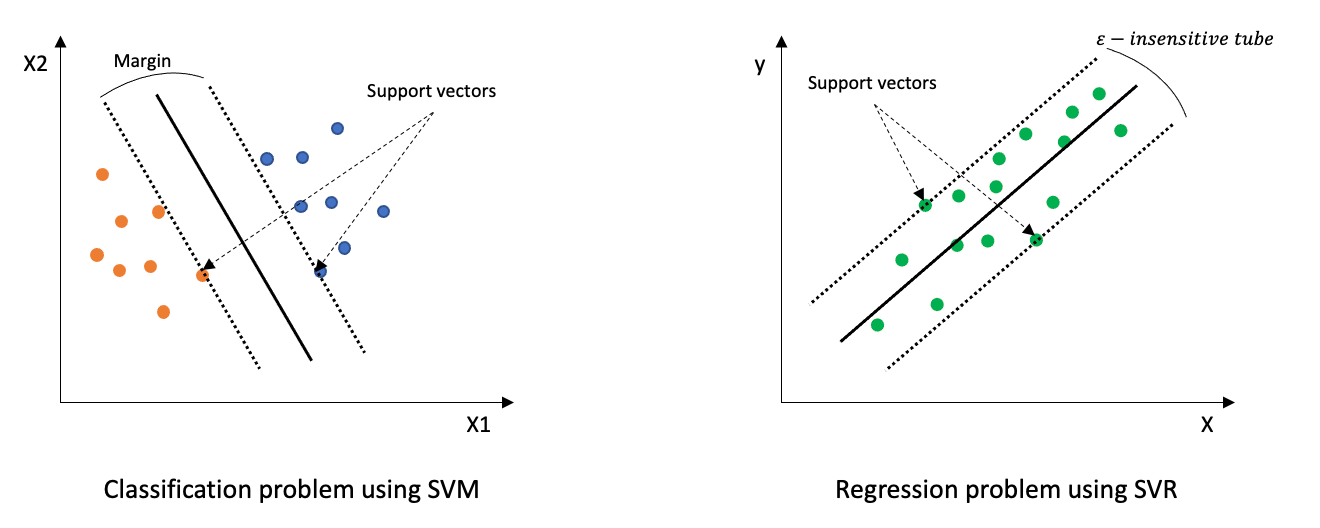

## SVM на практике

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data'
col_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'target']
iris = pd.read_csv(url, header=None, names=col_names)
iris

,sepal_length,sepal_width,petal_length,petal_width,target
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
iris['target'].value_counts()

,count
target,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [ ]:
iris = iris[iris['target'] != 'Iris-virginica']

In [ ]:
X = iris[['petal_length', 'petal_width']].values
y = iris['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(80, 2) (80,)
(20, 2) (20,)


In [ ]:
print(np.unique(y_train))
print(np.unique(y_test))

['Iris-setosa' 'Iris-versicolor']
['Iris-setosa' 'Iris-versicolor']


Конструктор алгоритма выглядит следующим образом:

`class sklearn.svm.SVC(*, C=1.0, kernel='rbf', degree=3, gamma='scale', coef0=0.0, shrinking=True, probability=False, tol=0.001, cache_size=200, class_weight=None, verbose=False, max_iter=-1, decision_function_shape='ovr', break_ties=False, random_state=None)`

- `C (default=1.0)` — коэффициент штрафа за ошибки.
Чем выше C, тем жестче модель пытается разделить данные, но возрастает риск переобучения.
Чем ниже C, тем больше модель допускает ошибки, но становится более обобщенной.
- `kernel (default='rbf')` — выбор ядра. `linear`, `poly`, `rbf`, `sigmoid`, или собственная функция.
- `degree (default=3)` — степень полинома (для полиномиального ядра).
- `gamma (default='scale')` — определяет, насколько далеко влияет одно обучающее значение.
    - Маленькое γ — более гладкие границы.
    - Большое γ — более сложные границы, но выше риск переобучения.
- `coef0 (default=0.0)` — сдвиг для полиномиального и сигмоидного ядра.
- `shrinking (default=True)` — ускоряет обучение, отбрасывая малозначимые векторы.
- `probability (default=False)` — позволяет возвращать вероятности классов (дороже по вычислениям).
- `tol (default=0.001)` — допустимое отклонение для сходимости алгоритма.
- `cache_size (default=200)` — размер кэша в МБ для ускорения вычислений ядра.
- `class_weight (default=None)` — веса классов для несбалансированных данных.
- `verbose (default=False)` — выводить ли логи в консоль.
- `max_iter (default=-1)` — максимальное число итераций (-1 = без ограничений).
- `decision_function_shape (default='ovr')` — стратегия для многоклассовой классификации:
    - 'ovr' (one-vs-rest) или 'ovo' (one-vs-one).
- `break_ties (default=False)` — решать, что делать в случае ничьей при ovr.
- `random_state (default=None)` — фиксирует случайность для воспроизводимости.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, SVR
import seaborn as sns

# Обучим SVM с линейным ядром
model = SVC(kernel='linear',
            C=100)

model.fit(X_train, y_train)

SVC(C=100, kernel='linear')

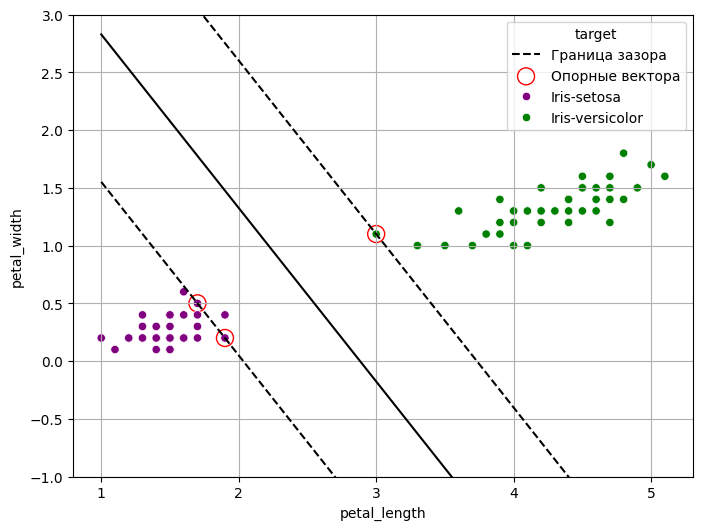

In [ ]:
# Получим параметры разделяющей гиперплоскости
w = model.coef_[0]
b = model.intercept_[0]

# Норма вектора весов для правильного расчёта зазора
w_norm = 2/np.linalg.norm(w)

# Построим линии для визуализации
x_min, x_max = 1, 5
x_points = np.linspace(x_min, x_max, 100)

y_decision_boundary = -(w[0] * x_points + b) / w[1]
y_margin_positive = -(w[0] * x_points + b - 1) / w[1]
y_margin_negative = -(w[0] * x_points + b + 1) / w[1]

# Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue')

# Рисуем разделяющую линию и зазоры
plt.plot(x_points, y_decision_boundary, 'k-')
plt.plot(x_points, y_margin_positive, 'k--', label='Граница зазора')
plt.plot(x_points, y_margin_negative, 'k--')

# Отметим опорные векторы
support_vectors = model.support_vectors_
plt.scatter(support_vectors[:, 0], support_vectors[:, 1], s=150, facecolors='none', edgecolors='red', label='Опорные вектора')

sns.scatterplot(
    data=iris,
    x='petal_length',
    y='petal_width',
    hue='target',
    palette={"Iris-setosa": "purple", "Iris-versicolor": "green"}
)
plt.ylim(-1, 3)  # Уменьшаем масштаб по оси y

plt.grid()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.datasets import load_iris

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target

# Разбиение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучение модели
model = SVC(kernel='rbf', C=100, gamma='scale')
model.fit(X_train, y_train)

# Оценка модели
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.2f}')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.89      0.94         9
           2       0.92      1.00      0.96        11

    accuracy                           0.97        30
   macro avg       0.97      0.96      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy: 0.97


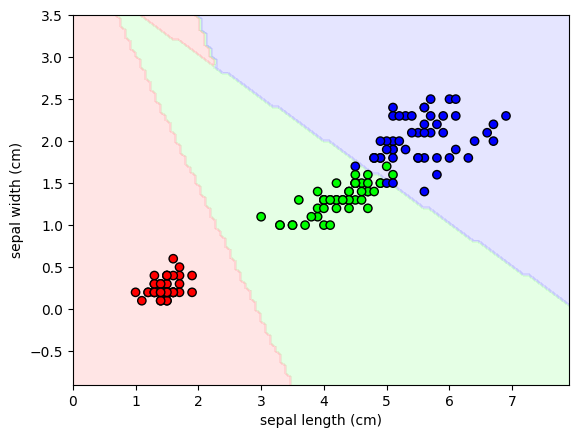

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X_vis = X[:, 2:4]
X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(X_vis, y, test_size=0.2, random_state=42)

model_vis = SVC(kernel='linear', C=1000, gamma='scale')
model_vis.fit(X_train_vis, y_train_vis)

# Построение границы решений
x_min, x_max = X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1
y_min, y_max = X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
Z = model_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Визуализация
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']))
plt.scatter(X_vis[:, 0], X_vis[:, 1], c=y, edgecolors='k', cmap=ListedColormap(['#FF0000', '#00FF00', '#0000FF']))
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.show()

Конструктор класса для регрессии:

`class sklearn.svm.SVR(*, kernel='rbf', degree=3, C=1.0, epsilon=0.1, shrinking=True, tol=0.001, cache_size=200, coef0=0.0, verbose=False, max_iter=-1)`

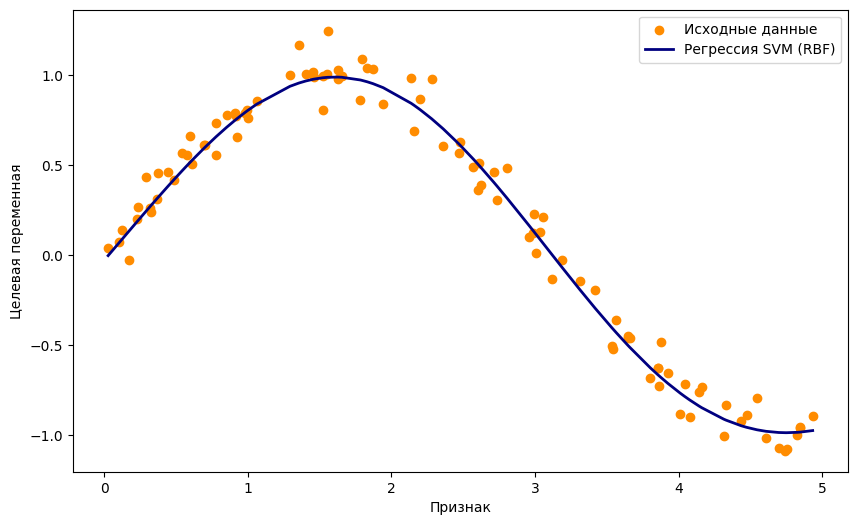

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split

# Генерация синтетических данных
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Разделение данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Создание и обучение модели SVM-регрессии
svr_rbf = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
svr_rbf.fit(X_train, y_train)

# Предсказания
y_pred = svr_rbf.predict(X_test)

# Визуализация результата
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkorange', label='Исходные данные')
plt.plot(X, svr_rbf.predict(X), color='navy', lw=2, label='Регрессия SVM (RBF)')
plt.xlabel('Признак')
plt.ylabel('Целевая переменная')
plt.legend()
plt.show()

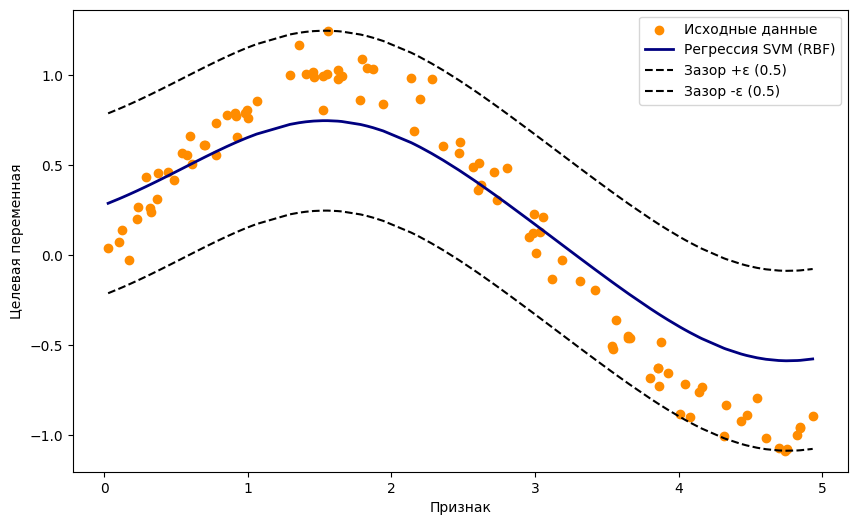

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVR

# Генерация синтетических данных
np.random.seed(42)
X = np.sort(5 * np.random.rand(100, 1), axis=0)
y = np.sin(X).ravel() + np.random.normal(0, 0.1, X.shape[0])

# Создание и обучение модели SVM-регрессии
epsilon = 0.5
svr_rbf = SVR(kernel='rbf', C=1000, gamma=0.5, epsilon=epsilon)
svr_rbf.fit(X, y)

# Предсказания
y_pred = svr_rbf.predict(X)

# Визуализация результата
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='darkorange', label='Исходные данные')
plt.plot(X, y_pred, color='navy', lw=2, label='Регрессия SVM (RBF)')

# Построение зазора
plt.plot(X, y_pred + epsilon, 'k--', label=f'Зазор +ε ({epsilon})')
plt.plot(X, y_pred - epsilon, 'k--', label=f'Зазор -ε ({epsilon})')

plt.xlabel('Признак')
plt.ylabel('Целевая переменная')
plt.legend()
plt.show()